In [1]:
# 1 Частина
import micropip
await micropip.install('seaborn')

In [2]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix)
%matplotlib inline

In [3]:
df = pd.read_csv("loan_data.csv")

print("Розмір датасету:", df.shape)
df.head()
df.info()
df.isnull().sum()

Розмір датасету: (381, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            381 non-null    object 
 1   Gender             376 non-null    object 
 2   Married            381 non-null    object 
 3   Dependents         373 non-null    object 
 4   Education          381 non-null    object 
 5   Self_Employed      360 non-null    object 
 6   ApplicantIncome    381 non-null    int64  
 7   CoapplicantIncome  381 non-null    float64
 8   LoanAmount         381 non-null    float64
 9   Loan_Amount_Term   370 non-null    float64
 10  Credit_History     351 non-null    float64
 11  Property_Area      381 non-null    object 
 12  Loan_Status        381 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 26.9+ KB


Loan_ID               0
Gender                5
Married               0
Dependents            8
Education             0
Self_Employed        21
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     11
Credit_History       30
Property_Area         0
Loan_Status           0
dtype: int64

In [4]:
df_clean = df.copy()

num_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df_clean.select_dtypes(include=["object"]).columns
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

df_clean.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [5]:
le = LabelEncoder()
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

df_clean.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
1,1,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
2,2,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
3,3,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1
4,4,1,1,0,1,0,2333,1516.0,95.0,360.0,1.0,2,1


In [6]:
X = df_clean.drop("Loan_Status", axis=1)
y = df_clean["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)
X_train.shape, X_test.shape

((285, 12), (96, 12))

In [7]:
rf_base = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

t0 = time.perf_counter()
rf_base.fit(X_train, y_train)
t1 = time.perf_counter()
y_pred_base = rf_base.predict(X_test)
t2 = time.perf_counter()

print("Random Forest без PCA")
print("Accuracy:", accuracy_score(y_test, y_pred_base))
print("Навчання:", round(t1 - t0, 4), "c")
print("Передбачення:", round(t2 - t1, 6), "c")
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_base))
print("Classification report:\n", classification_report(y_test, y_pred_base, digits=4))

Random Forest без PCA
Accuracy: 0.8541666666666666
Навчання: 0.7956 c
Передбачення: 0.0265 c
Confusion matrix:
 [[14 14]
 [ 0 68]]
Classification report:
               precision    recall  f1-score   support

           0     1.0000    0.5000    0.6667        28
           1     0.8293    1.0000    0.9067        68

    accuracy                         0.8542        96
   macro avg     0.9146    0.7500    0.7867        96
weighted avg     0.8791    0.8542    0.8367        96



In [8]:
pipe_pca_rf = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=42)),
    ("rf", RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        random_state=42
    ))
])

In [9]:
t0 = time.perf_counter()
pipe_pca_rf.fit(X_train, y_train)
t1 = time.perf_counter()

y_pred_pca = pipe_pca_rf.predict(X_test)
t2 = time.perf_counter()

pca = pipe_pca_rf.named_steps["pca"]

print("Random Forest з PCA")
print(f"Кількість компонент PCA: {pca.n_components_} з {X.shape[1]}")
print(f"Збережена дисперсія: {pca.explained_variance_ratio_.sum():.3f}")
print("Accuracy:", accuracy_score(y_test, y_pred_pca))
print("Навчання:", round(t1 - t0, 4), "c")
print("Передбачення:", round(t2 - t1, 6), "c")
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_pca))
print("Classification report:\n", classification_report(y_test, y_pred_pca, digits=4))
# Зменшення розмірності за допомогою PCA не покращило якість класифікації Random Forest.Точність знизилась і це пояснюється тим, 
#що Random Forest є деревним алгоритмом і добре працює з вихідними ознаками, включаючи їх нелінійні взаємозв’язки, які частково втрачаються після PCA.

Random Forest з PCA
Кількість компонент PCA: 11 з 12
Збережена дисперсія: 0.963
Accuracy: 0.8333333333333334
Навчання: 0.9142 c
Передбачення: 0.0321 c
Confusion matrix:
 [[14 14]
 [ 2 66]]
Classification report:
               precision    recall  f1-score   support

           0     0.8750    0.5000    0.6364        28
           1     0.8250    0.9706    0.8919        68

    accuracy                         0.8333        96
   macro avg     0.8500    0.7353    0.7641        96
weighted avg     0.8396    0.8333    0.8174        96



   Зменшення розмірності за допомогою PCA не покращило якість класифікації Random Forest. Точність знизилась з 0.85 до 0.83. Це пояснюється тим, що Random Forest є деревним алгоритмом, їх нелінійні взаємозв’язки можуть встрачатись частково після PCA.
   Навчання не пришвидшилось, а час навчання збільшився через додатковий етап масштабування. Оскільки початкова кількість ознак була тільки 12, застосування PCA не дало виграшу в продуктивності.
   Так, точність класифікації знизилась. Це помітно для класу Loan_Status = 0, де recall залишився низьким. Це свідчить про те, що частина важливої інформації була втрачена під час лінійного зниження розмірності.

In [10]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.shape

(381, 12)

In [12]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1000,
    init="pca",
    random_state=42
)
tsne_result = tsne.fit_transform(X_scaled)

In [13]:
tsne_df = pd.DataFrame({
    "tsne_1": tsne_result[:, 0],
    "tsne_2": tsne_result[:, 1],
    "Loan_Status": y
})

tsne_df.head()

,tsne_1,tsne_2,Loan_Status
0,-12.645223,8.011560,0
1,17.756460,-14.676534,1
2,16.708691,12.456754,1
3,-17.831079,-0.989014,1
4,16.941441,12.336555,1


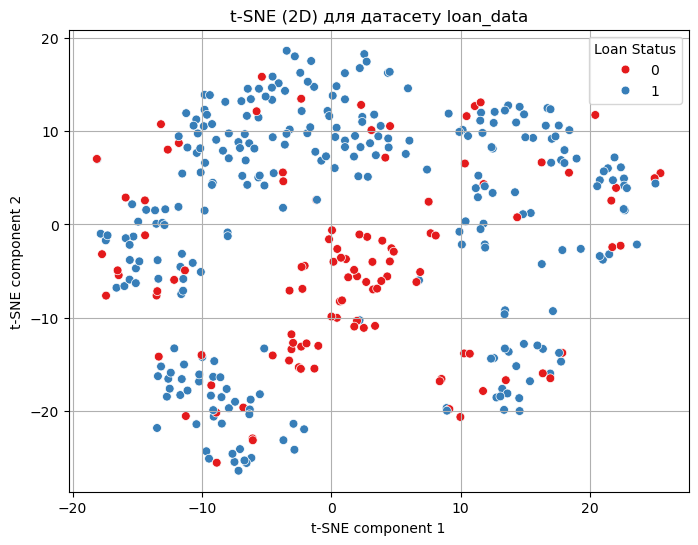

In [14]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="tsne_1",
    y="tsne_2",
    hue="Loan_Status",
    data=tsne_df,
    palette="Set1",
    s=40
)
plt.title("t-SNE (2D) для датасету loan_data")
plt.xlabel("t-SNE component 1")
plt.ylabel("t-SNE component 2")
plt.legend(title="Loan Status")
plt.grid(True)
plt.show()


In [15]:
for k, v in tsne.get_params().items():
    print(f"{k} = {v}")

angle = 0.5
early_exaggeration = 12.0
init = pca
learning_rate = 200
max_iter = 1000
method = barnes_hut
metric = euclidean
metric_params = None
min_grad_norm = 1e-07
n_components = 2
n_iter_without_progress = 300
n_jobs = None
perplexity = 30
random_state = 42
verbose = 0


   Алгоритм t-SNE відображає локальну структуру даних у двовимірному просторі. Візуалізація показує нам, що відбувається тільки часткове розділення класів. Також спостерігається значне перекриття, це знову свідчить про те, що дані не є лінійно відокремлюваними.

Image shape: (384, 612, 3)
dtype: uint8


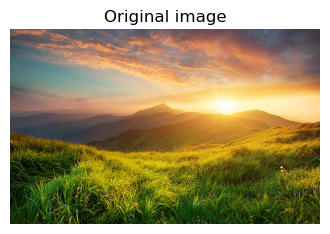

In [16]:
# 2 Частина
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

img = plt.imread("image.jpg")
print("Image shape:", img.shape)
print("dtype:", img.dtype)

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.axis("off")
plt.title("Original image")
plt.show()

In [17]:
data = img / 255.0

pixels = data.reshape(-1, 3)

print("Pixels shape:", pixels.shape)

Pixels shape: (235008, 3)


In [18]:
def quantize_image(pixels, img_shape, k):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(pixels)

    new_colors = kmeans.cluster_centers_[kmeans.labels_]
    quantized_img = new_colors.reshape(img_shape)
    return quantized_img

/lib/python3.13/site-packages/threadpoolctl.py:1123: RuntimeWarning: JsProxy.as_object_map() is deprecated. Use as_py_json() instead.
  for filepath in LDSO.loadedLibsByName.as_object_map():


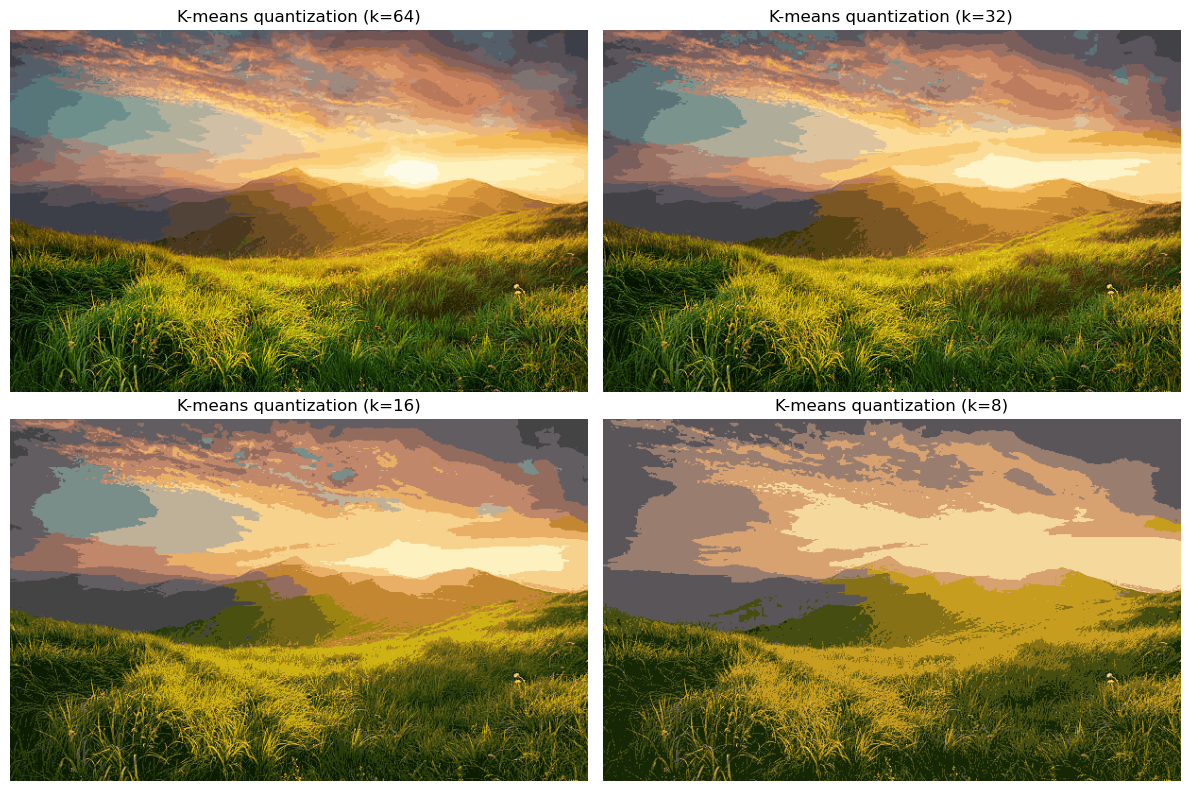

In [19]:
levels = [64, 32, 16, 8]

plt.figure(figsize=(12, 8))

for i, k in enumerate(levels, 1):
    quant_img = quantize_image(pixels, img.shape, k)

    plt.subplot(2, 2, i)
    plt.imshow(quant_img)
    plt.axis("off")
    plt.title(f"K-means quantization (k={k})")
plt.tight_layout()
plt.show()

In [20]:
orig_colors = np.unique(img.reshape(-1, 3), axis=0)
print("Унікальних кольорів:", orig_colors.shape[0])

for k in levels:
    q_img = quantize_image(pixels, img.shape, k)
    q_colors = np.unique(q_img.reshape(-1, 3), axis=0)
    print(f"k={k}: унікальних кольорів =", q_colors.shape[0])

Унікальних кольорів: 114914
k=64: унікальних кольорів = 64
k=32: унікальних кольорів = 32
k=16: унікальних кольорів = 16
k=8: унікальних кольорів = 8


   Як бачимо з зоображень при зменшенні кількості кластерів зображення поступово втрачає дрібні деталі та плавні переходи кольорів. Але всеодно загальна структура об’єктів зберігаться. Тобто чим менше значення k, тим сильніше спрощується кольорова палітра. При k=64 зображення майже не відрізняється від оригіналу, а при k=8 загальна картина дуже зливається.

In [21]:
# 3 Частина
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from wordcloud import WordCloud

In [22]:
fake_df = pd.read_csv("Fake.csv")
true_df = pd.read_csv("True.csv")

fake_df["label"] = 0
true_df["label"] = 1

print(fake_df.shape, true_df.shape)

(23481, 5) (21417, 5)


In [23]:
df = pd.concat([fake_df, true_df], axis=0)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [24]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text

df["clean_text"] = df["text"].apply(clean_text)

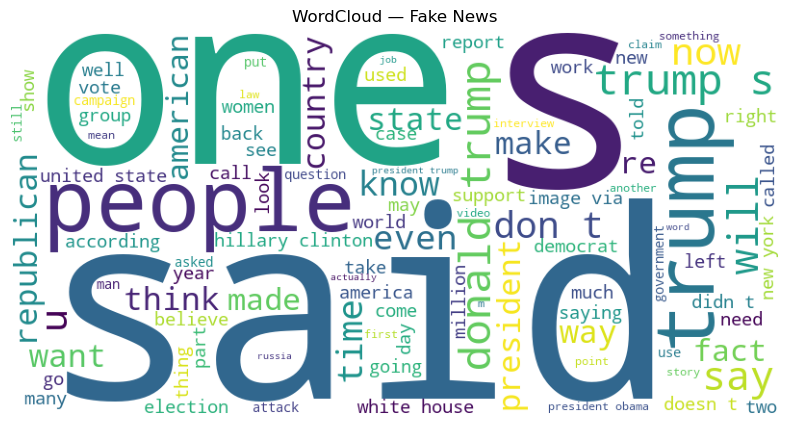

In [25]:
fake_text = " ".join(df[df["label"] == 0]["clean_text"])
wordcloud_fake = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100
).generate(fake_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_fake)
plt.axis("off")
plt.title("WordCloud — Fake News")
plt.show()

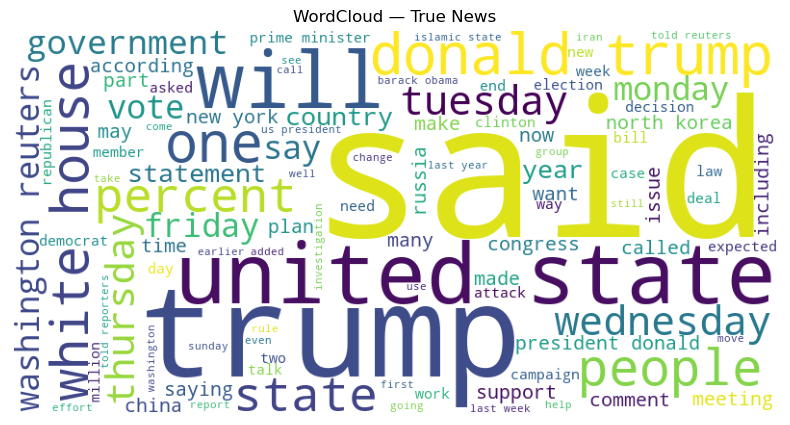

In [26]:
true_text = " ".join(df[df["label"] == 1]["clean_text"])
wordcloud_true = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100
).generate(true_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_true)
plt.axis("off")
plt.title("WordCloud — True News")
plt.show()

In [27]:
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

tfidf = TfidfVectorizer(
    stop_words="english",
    max_df=0.7,
    min_df=10
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)

(35918, 26778)


In [28]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

In [29]:
print(classification_report(y_test, y_pred, target_names=["Fake", "True"]))

              precision    recall  f1-score   support

        Fake       0.99      0.98      0.99      4710
        True       0.98      0.99      0.98      4270

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980

